Imports all the libraries we need

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

Now we will load our data csv file

In [2]:
df = pd.read_csv("_ Double-Parking in Cairo_ A Research Survey   (Responses) - Form Responses 1.csv")

We will rename the columns for easy analysis coding

In [3]:
df.columns = [
    'Timestamp', 'Gender', 'Age', 'Years_Driving',
    'Days_Per_Week', 'Incidents_Per_Month', 'Wait_Time_Min',
    'Times_Late', 'Stress_Level', 'Behavior', 'Area'
]

We will Drop the timestamp column we don't need it

In [4]:
df = df.drop(columns=['Timestamp'])

Prints the first 5 rows to check the data now

In [5]:
print("Data loaded successfully!")
print("Shape:", df.shape)
print()
print(df.head())

Data loaded successfully!
Shape: (54, 10)

  Gender    Age  Years_Driving Days_Per_Week  Incidents_Per_Month  \
0   Male  18–25              2      3–4 days                    4   
1   Male  18–25              4     Every day                    2   
2   Male  18–25              8     Every day                   30   
3   Male  18–25              5      5–6 days                    5   
4   Male  18–25              5      3–4 days                   30   

   Wait_Time_Min  Times_Late  Stress_Level                    Behavior  \
0             15           2             5              Wait patiently   
1             30           0             5  Ask nearby people for help   
2             20          30             9             Honk repeatedly   
3             30          14             9         Call traffic police   
4             15          20             8  Ask nearby people for help   

                                    Area  
0           New Cairo / Fifth Settlement  
1          

The Area column has messy free text entries like madinty and Maadi and Mokattam that people typed manually. We need to group them into clean standard categories.

In [6]:
area_mapping = {
    'New Cairo / Fifth Settlement': 'New Cairo / Fifth Settlement',
    'Nasr City / Heliopolis / Masr ElGdeda': 'Nasr City / Heliopolis',
    'Giza / Dokki / Mohandessin / Maady': 'Giza / Dokki / Mohandessin',
    'Downtown Cairo': 'Downtown Cairo',
    '6th of October / Sheikh Zayed': '6th of October / Sheikh Zayed',
    'Zahraa elmaadi': 'Giza / Dokki / Mohandessin',
    'madinty': 'New Cairo / Fifth Settlement',
    'Maadi': 'Giza / Dokki / Mohandessin',
    'Mokttam/ Maady / 6th of October ': '6th of October / Sheikh Zayed',
    'Mokattam': 'Nasr City / Heliopolis',
    'New cairo and giza': 'New Cairo / Fifth Settlement'
}

df['Area'] = df['Area'].map(area_mapping) #This will replace the original values in the 'Area' column with the standardized ones based on the mapping we provided.

print("Area column cleaned!")
print()
print(df['Area'].value_counts())

Area column cleaned!

Area
New Cairo / Fifth Settlement     35
Nasr City / Heliopolis            6
Giza / Dokki / Mohandessin        5
6th of October / Sheikh Zayed     5
Downtown Cairo                    3
Name: count, dtype: int64


Calculate Mean, Median, Mode for each numerical columns

In [7]:
print("Years Driving:")
print("Mean:", round(df['Years_Driving'].mean(), 2))
print("Median:", df['Years_Driving'].median())
print("Mode:", df['Years_Driving'].mode()[0])
print()

print("Incidents Per Month:")
print("Mean:", round(df['Incidents_Per_Month'].mean(), 2))
print("Median:", df['Incidents_Per_Month'].median())
print("Mode:", df['Incidents_Per_Month'].mode()[0])
print()

print("Wait Time (Minutes):")
print("Mean:", round(df['Wait_Time_Min'].mean(), 2))
print("Median:", df['Wait_Time_Min'].median())
print("Mode:", df['Wait_Time_Min'].mode()[0])
print()

print("Times Late Per Month:")
print("Mean:", round(df['Times_Late'].mean(), 2))
print("Median:", df['Times_Late'].median())
print("Mode:", df['Times_Late'].mode()[0])
print()

print("Stress Level (1-10):")
print("Mean:", round(df['Stress_Level'].mean(), 2))
print("Median:", df['Stress_Level'].median())
print("Mode:", df['Stress_Level'].mode()[0])

Years Driving:
Mean: 4.43
Median: 3.0
Mode: 2

Incidents Per Month:
Mean: 4.56
Median: 3.0
Mode: 3

Wait Time (Minutes):
Mean: 14.5
Median: 15.0
Mode: 15

Times Late Per Month:
Mean: 3.2
Median: 2.0
Mode: 0

Stress Level (1-10):
Mean: 7.26
Median: 8.0
Mode: 10


Chart 1: Distribution of Stress Levels (Histogram)

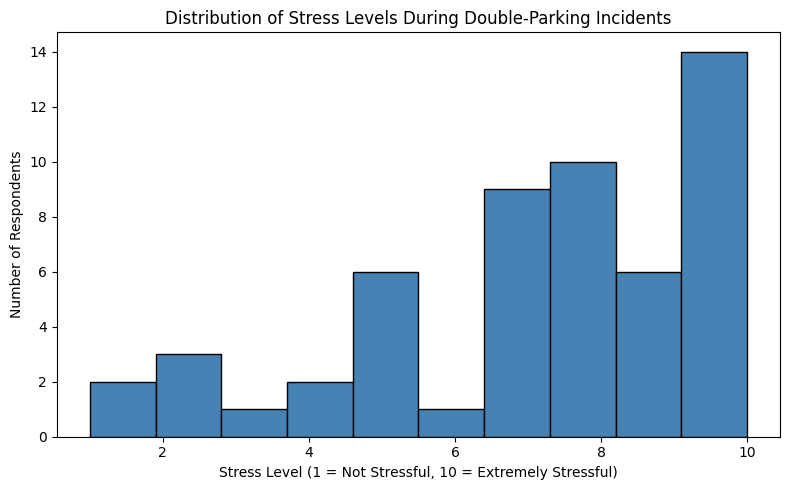

In [9]:
plt.figure(figsize=(8, 5))

plt.hist(df['Stress_Level'], bins=10, color='steelblue', edgecolor='black')

plt.title('Distribution of Stress Levels During Double-Parking Incidents')
plt.xlabel('Stress Level (1 = Not Stressful, 10 = Extremely Stressful)')
plt.ylabel('Number of Respondents')

plt.tight_layout()
plt.savefig('chart1_stress_distribution.png', dpi=150)
plt.show()

Chart 2 - What do drivers do when blocked?

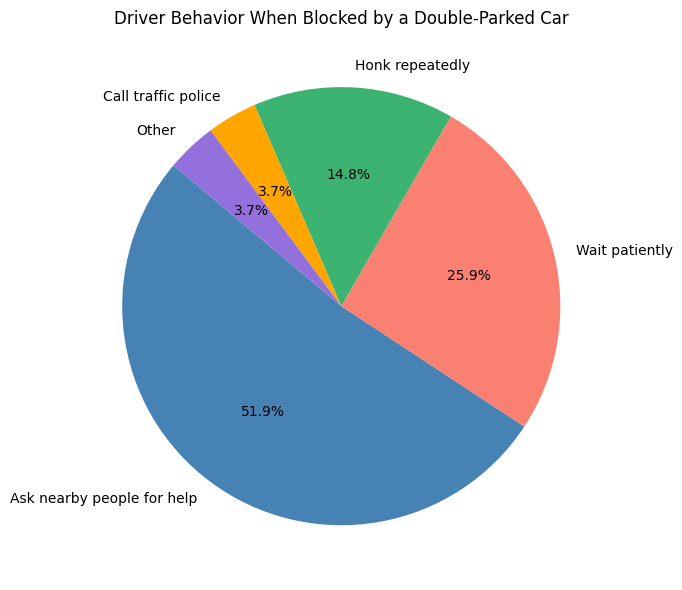

In [10]:
behavior_counts = df['Behavior'].value_counts()

plt.figure(figsize=(8, 6))

plt.pie(behavior_counts, 
        labels=behavior_counts.index, 
        autopct='%1.1f%%', 
        startangle=140,
        colors=['steelblue', 'salmon', 'mediumseagreen', 'orange', 'mediumpurple'])

plt.title('Driver Behavior When Blocked by a Double-Parked Car')

plt.tight_layout()
plt.savefig('chart2_behavior_pie.png', dpi=150)
plt.show()

Chart 3: Average Stress Level by Gender (Bar Chart)

Average Stress - Male: 6.94
Average Stress - Female: 7.8


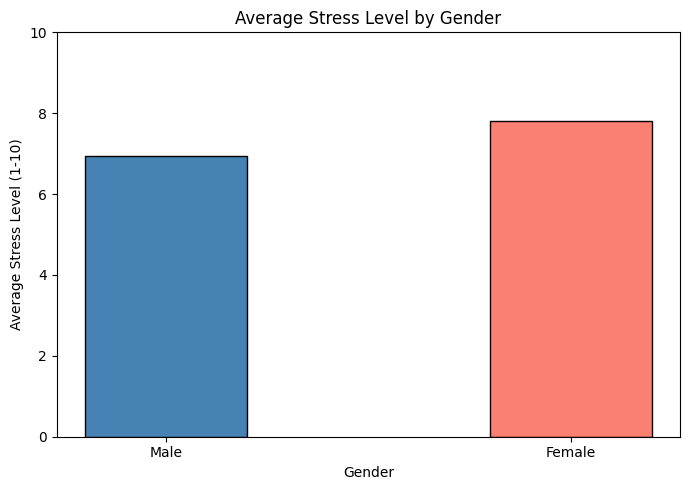

In [11]:
male_stress = df[df['Gender'] == 'Male']['Stress_Level'].mean()
female_stress = df[df['Gender'] == 'Female']['Stress_Level'].mean()

print("Average Stress - Male:", round(male_stress, 2))
print("Average Stress - Female:", round(female_stress, 2))

genders = ['Male', 'Female']
values = [male_stress, female_stress]

plt.figure(figsize=(7, 5))
plt.bar(genders, values, color=['steelblue', 'salmon'], edgecolor='black', width=0.4)
plt.title('Average Stress Level by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Stress Level (1-10)')
plt.ylim(0, 10)
plt.tight_layout() 
plt.savefig('chart3_stress_by_gender.png', dpi=150)
plt.show()

chart 4: Average Wait Time by Age Group (Bar Chart)

Average Wait Time - 18-25: 14.53 minutes
Average Wait Time - 26-35: 20.0 minutes
Average Wait Time - 46 and above: 10.33 minutes


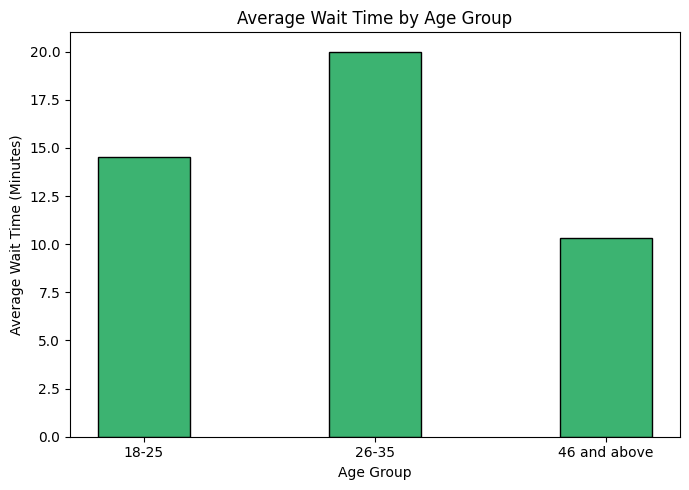

In [12]:
age_18_25 = df[df['Age'] == '18–25']['Wait_Time_Min'].mean()
age_26_35 = df[df['Age'] == '26–35']['Wait_Time_Min'].mean()
age_46 = df[df['Age'] == '46 and above']['Wait_Time_Min'].mean()

print("Average Wait Time - 18-25:", round(age_18_25, 2), "minutes")
print("Average Wait Time - 26-35:", round(age_26_35, 2), "minutes")
print("Average Wait Time - 46 and above:", round(age_46, 2), "minutes")

age_groups = ['18-25', '26-35', '46 and above']
wait_values = [age_18_25, age_26_35, age_46]

plt.figure(figsize=(7, 5))
plt.bar(age_groups, wait_values, color='mediumseagreen', edgecolor='black', width=0.4)
plt.title('Average Wait Time by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Wait Time (Minutes)')
plt.tight_layout()
plt.savefig('chart4_waittime_by_age.png', dpi=150)
plt.show()

Incidents Per Month by Area (Horizontal Bar)

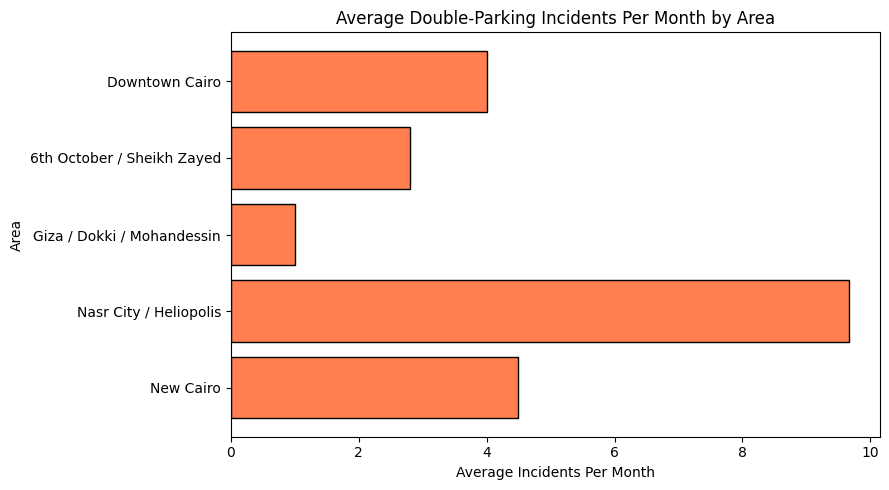

In [14]:
new_cairo = df[df['Area'] == 'New Cairo / Fifth Settlement']['Incidents_Per_Month'].mean()
nasr_city = df[df['Area'] == 'Nasr City / Heliopolis']['Incidents_Per_Month'].mean()
giza = df[df['Area'] == 'Giza / Dokki / Mohandessin']['Incidents_Per_Month'].mean()
october = df[df['Area'] == '6th of October / Sheikh Zayed']['Incidents_Per_Month'].mean()
downtown = df[df['Area'] == 'Downtown Cairo']['Incidents_Per_Month'].mean()

areas = ['New Cairo', 'Nasr City / Heliopolis', 'Giza / Dokki / Mohandessin', '6th October / Sheikh Zayed', 'Downtown Cairo']
incidents = [new_cairo, nasr_city, giza, october, downtown]

plt.figure(figsize=(9, 5))
plt.barh(areas, incidents, color='coral', edgecolor='black')
plt.title('Average Double-Parking Incidents Per Month by Area')
plt.xlabel('Average Incidents Per Month')
plt.ylabel('Area')
plt.tight_layout()
plt.savefig('chart5_incidents_by_area.png', dpi=150)
plt.show()

 Chart 6: Scatter Plot Incidents vs Stress Level

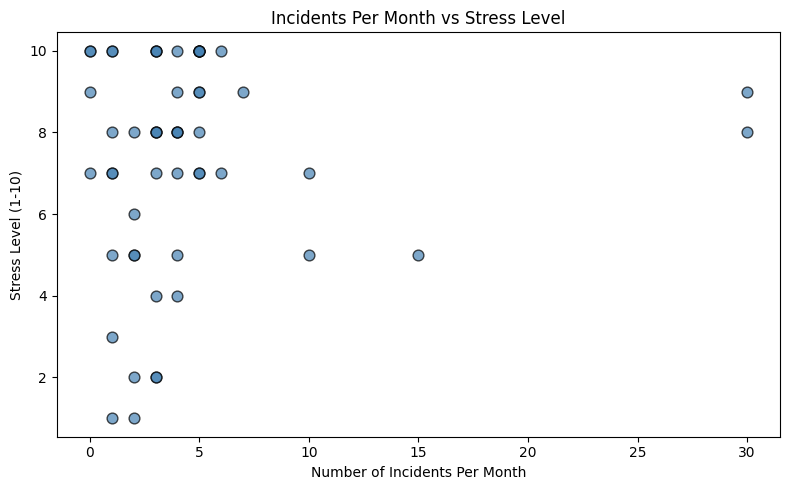

In [16]:
plt.figure(figsize=(8, 5))

plt.scatter(df['Incidents_Per_Month'], df['Stress_Level'], 
            color='steelblue', edgecolor='black', alpha=0.7, s=60)

plt.title('Incidents Per Month vs Stress Level')
plt.xlabel('Number of Incidents Per Month')
plt.ylabel('Stress Level (1-10)')

plt.tight_layout()
plt.savefig('chart6_incidents_vs_stress.png', dpi=150)
plt.show()

 Chart 7: Box Plot — Wait Time by Gender

C:\Users\HP\AppData\Local\Temp\ipykernel_6148\3706482174.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([male_wait, female_wait],


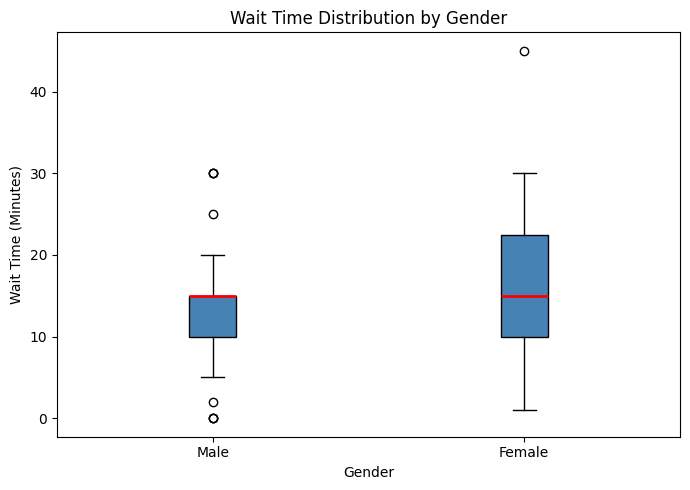

In [17]:
male_wait = df[df['Gender'] == 'Male']['Wait_Time_Min']
female_wait = df[df['Gender'] == 'Female']['Wait_Time_Min']

plt.figure(figsize=(7, 5))

plt.boxplot([male_wait, female_wait], 
            labels=['Male', 'Female'],
            patch_artist=True,
            boxprops=dict(facecolor='steelblue'),
            medianprops=dict(color='red', linewidth=2))

plt.title('Wait Time Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Wait Time (Minutes)')

plt.tight_layout()
plt.savefig('chart7_waittime_boxplot.png', dpi=150)
plt.show()

Summary

In [19]:
print("KEY FINDINGS SUMMARY")
print()
print("Total Responses:", len(df))
print()
print("Incidents Per Month - Mean:", round(df['Incidents_Per_Month'].mean(), 2))
print("Wait Time - Mean:", round(df['Wait_Time_Min'].mean(), 2), "minutes")
print("Stress Level - Mean:", round(df['Stress_Level'].mean(), 2), "out of 10")
print()
print("Average Stress - Male:", round(df[df['Gender'] == 'Male']['Stress_Level'].mean(), 2))
print("Average Stress - Female:", round(df[df['Gender'] == 'Female']['Stress_Level'].mean(), 2))
print()
print("Most affected area: Nasr City / Heliopolis")
print("Most common behavior: Ask nearby people for help")

KEY FINDINGS SUMMARY

Total Responses: 54

Incidents Per Month - Mean: 4.56
Wait Time - Mean: 14.5 minutes
Stress Level - Mean: 7.26 out of 10

Average Stress - Male: 6.94
Average Stress - Female: 7.8

Most affected area: Nasr City / Heliopolis
Most common behavior: Ask nearby people for help
